<a href="https://colab.research.google.com/github/asetya/BigData/blob/master/segmentation_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Segmentation with Basic Techniques

This notebook demonstrates three fundamental approaches to image segmentation in computer vision:
1. **Thresholding (Binarization)**: Global, Otsu's, and Adaptive (Gaussian) thresholding.
2. **Color-based Segmentation**: HSV color space masking.
3. **Edge and Contour Detection**: Canny edge detection and contour outlining.

Let's start by installing and importing the necessary libraries.

In [ ]:
# Install dependencies (OpenCV, numpy, matplotlib are usually pre-installed in Google Colab, but let's make sure they are up-to-date)
!pip install opencv-python-headless numpy matplotlib

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
print("Libraries imported successfully! Ready to segment.")

Libraries imported successfully! Ready to segment.


## 1. Generating a Synthetic Image

To make this notebook self-contained, we generate a synthetic color image with simple geometric shapes (a red circle, a green square, a blue triangle, and a white ring) on a dark background. To make it a realistic test case for segmentation, we add a spatial illumination gradient (varying brightness across the image) and some Gaussian noise.

In [ ]:
def generate_synthetic_image():
    width, height = 500, 500
    base_img = np.zeros((height, width, 3), dtype=np.uint8)

    # Draw shapes (OpenCV uses BGR format)
    # Red Circle (BGR: B=0, G=0, R=255)
    cv2.circle(base_img, (120, 120), 60, (0, 0, 255), -1)

    # Green Square (BGR: B=0, G=255, R=0)
    cv2.rectangle(base_img, (200, 200), (320, 320), (0, 255, 0), -1)

    # Blue Triangle (BGR: B=255, G=0, R=0)
    pts = np.array([[380, 380], [450, 280], [310, 280]], np.int32)
    cv2.fillPoly(base_img, [pts], (255, 0, 0))

    # White Ring
    cv2.circle(base_img, (350, 120), 45, (255, 255, 255), 8)

    clean_shapes = base_img.copy()

    # Add an illumination gradient
    x = np.linspace(0, 110, width)
    y = np.linspace(0, 110, height)
    xv, yv = np.meshgrid(x, y)
    gradient = (xv + yv).astype(np.uint8)

    degraded_img = base_img.copy()
    for i in range(3):
        degraded_img[:, :, i] = cv2.add(degraded_img[:, :, i], gradient)

    # Add Gaussian noise
    noise = np.random.normal(0, 8, degraded_img.shape).astype(np.int16)
    degraded_img = np.clip(degraded_img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return clean_shapes, degraded_img

clean_img, test_img = generate_synthetic_image()
print("Synthetic test image generated.")

Synthetic test image generated.


**1.A Upload the Image**

## 2. Segmenting using Thresholding

Thresholding converts a grayscale image into a binary image (black and white).
- **Global Thresholding**: Uses a single threshold value (e.g., 127) for every pixel. Fails under uneven lighting.
- **Otsu's Thresholding**: Analyzes the histogram to find the mathematically optimal single threshold value. Still struggles with spatial illumination gradients.
- **Adaptive Thresholding**: Computes a local threshold for small pixel neighborhoods (here we use a 101x101 window), which robustly handles lighting gradients and shadows.

In [ ]:
gray = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)

# 1. Global Thresholding
_, thresh_global = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 2. Otsu's Thresholding
otsu_val, thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Otsu's Threshold: {otsu_val}")

# 3. Adaptive Thresholding
thresh_adaptive = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 101, 2
)

Otsu's Threshold: 123.0


## 3. Color-Based Segmentation (HSV)

RGB color space is sensitive to lighting changes. Instead, we convert to **HSV (Hue, Saturation, Value)** space where color (Hue) is isolated from brightness (Value). Here, we define Hue bounds to extract only the green object.

In [ ]:
hsv = cv2.cvtColor(test_img, cv2.COLOR_BGR2HSV)

# Define range of green color in HSV
lower_green = np.array([35, 50, 50])
upper_green = np.array([85, 255, 255])

# Create mask and extract segment
green_mask = cv2.inRange(hsv, lower_green, upper_green)
green_segmented = cv2.bitwise_and(test_img, test_img, mask=green_mask)

## 4. Edge and Contour Detection

Edges represent places where the image intensity changes sharply.
- **Canny Edge Detection**: Finds boundaries by looking for local gradients and suppressing weak edges.
- **Contours**: Connects edge points to define closed shapes. We can then outline or count them.

In [ ]:
# Blur to reduce noise influence on edge detection
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# Find outer contours
contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on a copy of original image
contour_img = test_img.copy()
cv2.drawContours(contour_img, contours, -1, (255, 0, 255), 3)
print(f"Detected {len(contours)} contours.")

Detected 3 contours.


## 5. Visualizing the Comparison

Let's plot the original and all segmentation results side-by-side. (We convert OpenCV's BGR to RGB so the colors are rendered correctly in Matplotlib).

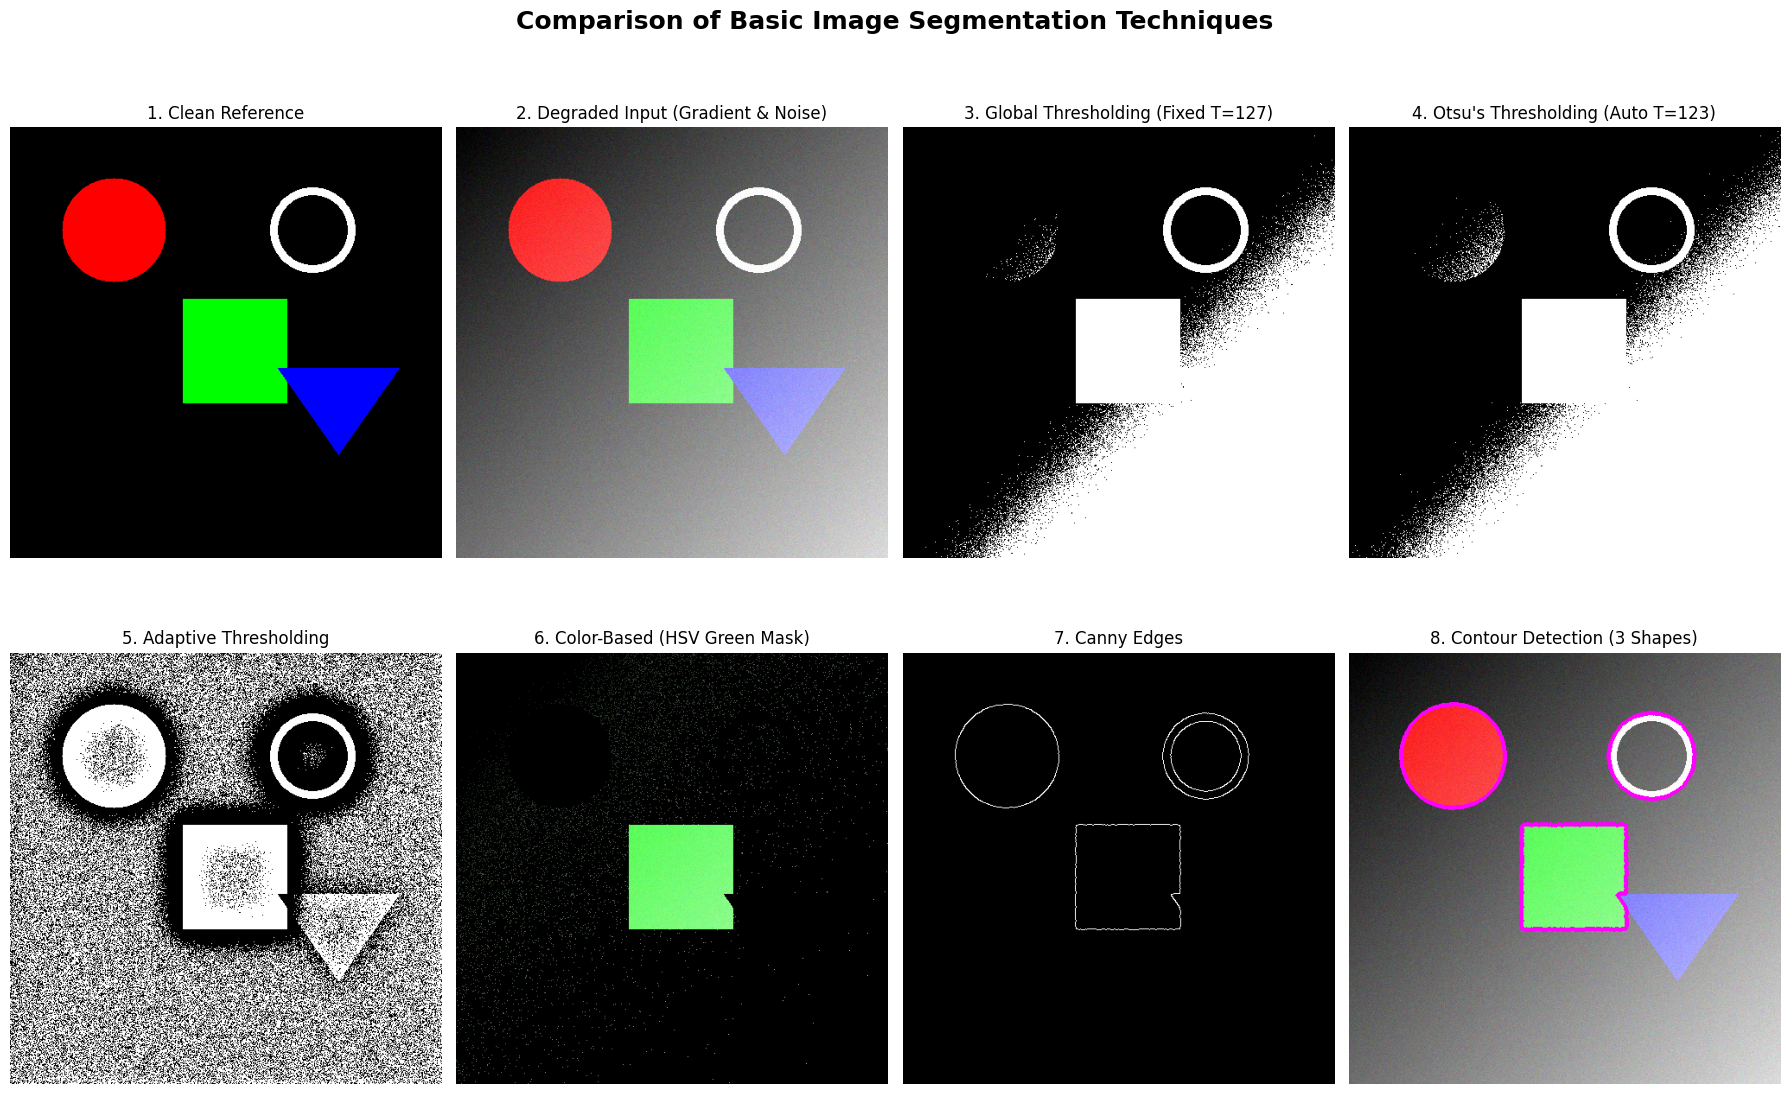

In [ ]:
rgb_test = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
rgb_clean = cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB)
rgb_green_seg = cv2.cvtColor(green_segmented, cv2.COLOR_BGR2RGB)
rgb_contour = cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(18, 12))
plt.suptitle("Comparison of Basic Image Segmentation Techniques", fontsize=18, fontweight='bold')

subplots = [
    (rgb_clean, "1. Clean Reference", None),
    (rgb_test, "2. Degraded Input (Gradient & Noise)", None),
    (thresh_global, "3. Global Thresholding (Fixed T=127)", "gray"),
    (thresh_otsu, f"4. Otsu's Thresholding (Auto T={int(otsu_val)})", "gray"),
    (thresh_adaptive, "5. Adaptive Thresholding", "gray"),
    (rgb_green_seg, "6. Color-Based (HSV Green Mask)", None),
    (edges, "7. Canny Edges", "gray"),
    (rgb_contour, f"8. Contour Detection ({len(contours)} Shapes)", None)
]

for idx, (img_data, title, cmap_val) in enumerate(subplots):
    plt.subplot(2, 4, idx + 1)
    if cmap_val:
        plt.imshow(img_data, cmap=cmap_val)
    else:
        plt.imshow(img_data)
    plt.title(title, fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()